# HW10-11 — компьютерное зрение в PyTorch

Этот ноутбук соответствует требованиям HW10-11 и создаёт артефакты в папке `homeworks/HW10-11/artifacts/`.

Выбор в этом решении:
- **Часть A:** `STL10`
- **Часть B:** `OxfordIIITPet`
- **Трек части B:** `segmentation`

Почему именно так:
- `STL10` — стандартный и достаточно компактный датасет для сравнения простой CNN, аугментаций и transfer learning.
- `OxfordIIITPet` — один из самых удобных вариантов для **segmentation**: есть понятный foreground-сценарий “pet vs background”, и можно аккуратно считать `mean IoU`, `pixel_precision`, `pixel_recall`.

In [1]:
from pathlib import Path
import copy
import json
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, models, transforms

try:
    from torchvision.models import ResNet18_Weights
except Exception:
    ResNet18_Weights = None

try:
    from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights
except Exception:
    DeepLabV3_ResNet50_Weights = None

from torchvision.transforms import InterpolationMode

plt.rcParams["figure.figsize"] = (10, 6)


def build_resnet18_pretrained():
    """Совместимо и с новым, и со старым API torchvision."""
    if ResNet18_Weights is not None:
        try:
            return models.resnet18(weights=ResNet18_Weights.DEFAULT)
        except TypeError:
            pass
        except Exception as e:
            print(f"Warning: failed to load ResNet18 with weights enum: {e}")

    try:
        return models.resnet18(pretrained=True)
    except Exception as e:
        print(f"Warning: failed to load pretrained ResNet18, fallback to random init: {e}")
        try:
            return models.resnet18(weights=None)
        except Exception:
            return models.resnet18(pretrained=False)


def build_deeplabv3_resnet50_pretrained():
    """Совместимо и с новым, и со старым API torchvision."""
    if DeepLabV3_ResNet50_Weights is not None:
        try:
            return models.segmentation.deeplabv3_resnet50(
                weights=DeepLabV3_ResNet50_Weights.DEFAULT
            ), DeepLabV3_ResNet50_Weights.DEFAULT
        except TypeError:
            pass
        except Exception as e:
            print(f"Warning: failed to load DeepLabV3 with weights enum: {e}")

    try:
        return models.segmentation.deeplabv3_resnet50(pretrained=True), None
    except Exception as e:
        print(f"Warning: failed to load pretrained DeepLabV3, fallback to random init: {e}")
        try:
            return models.segmentation.deeplabv3_resnet50(weights=None), None
        except Exception:
            return models.segmentation.deeplabv3_resnet50(pretrained=False), None


def get_pet_class_indices(seg_weights):
    """
    Для новых весов берём категории из meta.
    Для старых версий torchvision используем Pascal VOC индексы:
    cat=8, dog=12.
    """
    if seg_weights is not None:
        meta = getattr(seg_weights, "meta", None)
        if isinstance(meta, dict):
            categories = meta.get("categories")
            if categories and "cat" in categories and "dog" in categories:
                return categories.index("cat"), categories.index("dog")
    return 8, 12



In [2]:
def resolve_homework_root() -> Path:
    cwd = Path.cwd()
    if cwd.name == "HW10-11":
        return cwd
    candidate = cwd / "homeworks" / "HW10-11"
    candidate.mkdir(parents=True, exist_ok=True)
    return candidate

ROOT = resolve_homework_root()
ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = ROOT / "data"

for path in [ARTIFACTS_DIR, FIGURES_DIR, DATA_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
NUM_WORKERS = 0  # так надёжнее для локального запуска на разных ОС

FAST_RUN = device.type == "cpu"

CLASSIFICATION_BATCH_SIZE = 32 if device.type == "cuda" else 16
SEGMENTATION_BATCH_SIZE = 8 if device.type == "cuda" else 4

CNN_EPOCHS = 4 if not FAST_RUN else 1
RESNET_HEAD_EPOCHS = 3 if not FAST_RUN else 1
RESNET_FINETUNE_EPOCHS = 3 if not FAST_RUN else 1

TRAIN_LIMIT = None if not FAST_RUN else 800
VAL_LIMIT = None if not FAST_RUN else 200
TEST_LIMIT = None if not FAST_RUN else 400

SEGMENTATION_EVAL_LIMIT = None if not FAST_RUN else 60
SEG_IMAGE_SIZE = 256

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"ROOT: {ROOT.resolve()}")
print(f"Device: {device}")
print(f"FAST_RUN: {FAST_RUN}")
print(f"Seed: {SEED}")

ROOT: C:\Dev\mirea-ai\homeworks\HW10-11
Device: cpu
FAST_RUN: True
Seed: 42


## 1. Часть A — данные и sanity-check

Для классификации используется **STL10**.  
У датасета есть `train` и `test`, поэтому валидация делается как фиксированное разделение `train -> train/val` c seed.

100.0%


Part A batch shapes:
x.shape = (16, 3, 64, 64)
y.shape = (16,)
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


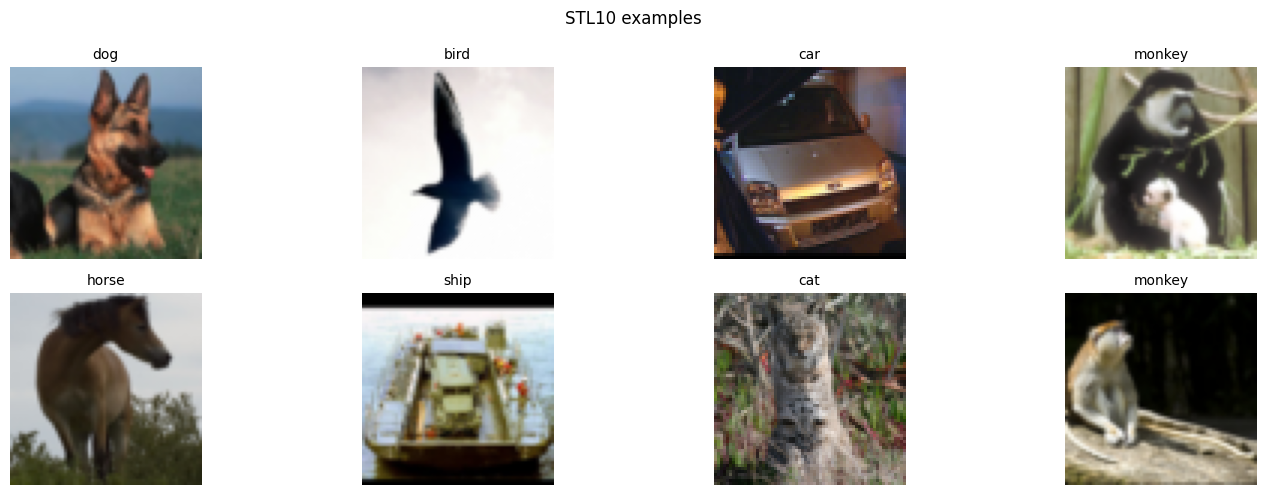

In [3]:
def make_subset(dataset, limit):
    if limit is None or limit >= len(dataset):
        return dataset
    return Subset(dataset, list(range(limit)))

def get_stl10_indices(seed: int, val_ratio: float = 0.2):
    base_ds = datasets.STL10(root=DATA_DIR, split="train", download=True)
    indices = np.arange(len(base_ds))
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)
    val_size = int(len(indices) * val_ratio)
    val_idx = indices[:val_size].tolist()
    train_idx = indices[val_size:].tolist()
    return train_idx, val_idx, base_ds.classes

stl10_train_idx, stl10_val_idx, STL10_CLASSES = get_stl10_indices(SEED)
NUM_CLASSES_A = len(STL10_CLASSES)

base_transform_cnn = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

aug_transform_cnn = transforms.Compose([
    transforms.Resize((72, 72)),
    transforms.RandomCrop((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

resnet_train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop((224, 224), scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

resnet_eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def build_stl10_split(train_transform, eval_transform):
    train_full = datasets.STL10(root=DATA_DIR, split="train", transform=train_transform, download=True)
    val_full = datasets.STL10(root=DATA_DIR, split="train", transform=eval_transform, download=True)
    test_full = datasets.STL10(root=DATA_DIR, split="test", transform=eval_transform, download=True)

    train_ds = Subset(train_full, stl10_train_idx)
    val_ds = Subset(val_full, stl10_val_idx)
    test_ds = test_full

    train_ds = make_subset(train_ds, TRAIN_LIMIT)
    val_ds = make_subset(val_ds, VAL_LIMIT)
    test_ds = make_subset(test_ds, TEST_LIMIT)
    return train_ds, val_ds, test_ds

train_cnn_base, val_cnn_base, test_cnn_base = build_stl10_split(
    train_transform=base_transform_cnn,
    eval_transform=base_transform_cnn,
)

train_cnn_aug, val_cnn_aug, test_cnn_aug = build_stl10_split(
    train_transform=aug_transform_cnn,
    eval_transform=base_transform_cnn,
)

train_resnet, val_resnet, test_resnet = build_stl10_split(
    train_transform=resnet_train_transform,
    eval_transform=resnet_eval_transform,
)

loaders_a = {
    "cnn_base": {
        "train": DataLoader(train_cnn_base, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        "val": DataLoader(val_cnn_base, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        "test": DataLoader(test_cnn_base, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
    },
    "cnn_aug": {
        "train": DataLoader(train_cnn_aug, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        "val": DataLoader(val_cnn_aug, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        "test": DataLoader(test_cnn_aug, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
    },
    "resnet": {
        "train": DataLoader(train_resnet, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        "val": DataLoader(val_resnet, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        "test": DataLoader(test_resnet, batch_size=CLASSIFICATION_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
    },
}

images_a, labels_a = next(iter(loaders_a["cnn_base"]["train"]))
print("Part A batch shapes:")
print("x.shape =", tuple(images_a.shape))
print("y.shape =", tuple(labels_a.shape))
print("Classes:", STL10_CLASSES)

def show_image_grid(images, labels, class_names, n=8, title="STL10 examples"):
    n = min(n, len(images))
    fig, axes = plt.subplots(2, math.ceil(n / 2), figsize=(15, 5))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for i in range(n):
        img = images[i].permute(1, 2, 0).clamp(0, 1).numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[int(labels[i])], fontsize=10)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show_image_grid(images_a, labels_a, STL10_CLASSES, n=8)

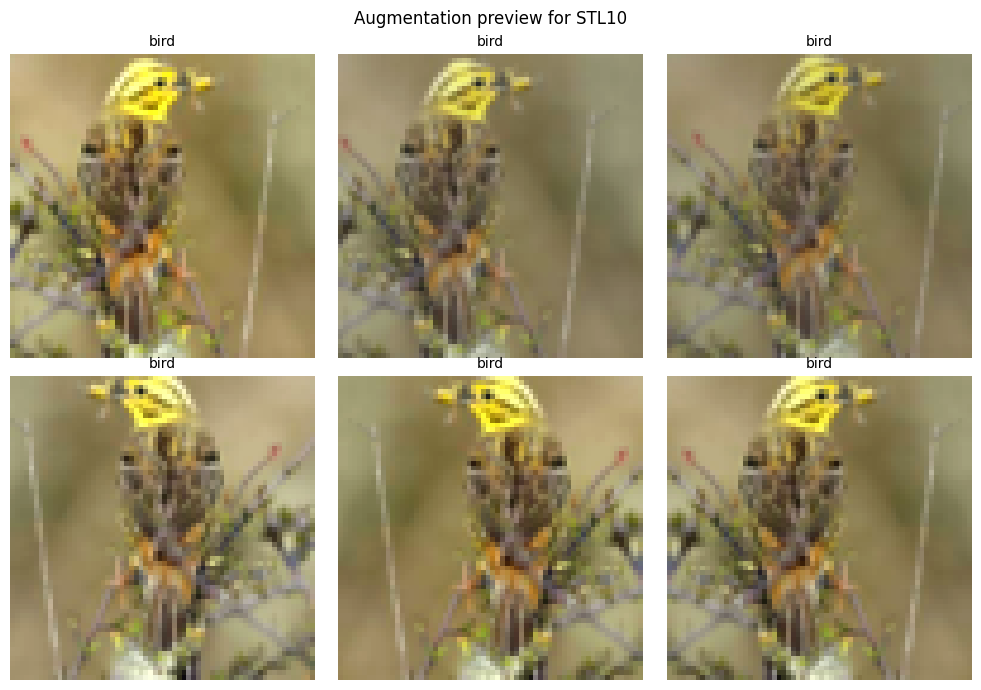

Saved: c:\Dev\mirea-ai\homeworks\HW10-11\artifacts\figures\augmentations_preview.png


In [4]:
preview_ds = datasets.STL10(root=DATA_DIR, split="train", download=True)
preview_image, preview_label = preview_ds[0]

preview_aug_images = [aug_transform_cnn(preview_image) for _ in range(6)]
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, aug_img in zip(axes.flatten(), preview_aug_images):
    ax.imshow(aug_img.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.axis("off")
    ax.set_title(STL10_CLASSES[preview_label], fontsize=10)
fig.suptitle("Augmentation preview for STL10")
fig.tight_layout()
augmentations_path = FIGURES_DIR / "augmentations_preview.png"
fig.savefig(augmentations_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {augmentations_path}")

## 2. Модели и функции обучения для части A

Эксперименты:
- **C1:** simple CNN + base transforms
- **C2:** simple CNN + augmentations
- **C3:** pretrained ResNet18, обучается только `fc`
- **C4:** pretrained ResNet18, partial fine-tuning (`layer4 + fc`)

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    return {
        "loss": total_loss / max(total_samples, 1),
        "accuracy": total_correct / max(total_samples, 1),
    }

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    return {
        "loss": total_loss / max(total_samples, 1),
        "accuracy": total_correct / max(total_samples, 1),
    }

def fit_classification_experiment(
    experiment_id,
    model,
    loaders,
    epochs,
    lr,
    optimizer_name="Adam",
    weight_decay=0.0,
    notes="",
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "AdamW":
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)

    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = -1.0

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, loaders["train"], criterion, optimizer, device)
        val_metrics = evaluate(model, loaders["val"], criterion, device)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }
        history.append(row)

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{experiment_id} | epoch {epoch:02d}/{epochs:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f}"
        )

    return {
        "experiment_id": experiment_id,
        "history": pd.DataFrame(history),
        "best_state_dict": best_state,
        "best_val_accuracy": best_val_accuracy,
        "optimizer": optimizer_name,
        "lr": lr,
        "epochs_trained": epochs,
        "notes": notes,
    }

def plot_history(history_df, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="train_accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="val_accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

In [6]:
classification_results = {}

# C1
model_c1 = SimpleCNN(num_classes=NUM_CLASSES_A)
classification_results["C1"] = fit_classification_experiment(
    experiment_id="C1",
    model=model_c1,
    loaders=loaders_a["cnn_base"],
    epochs=CNN_EPOCHS,
    lr=1e-3,
    optimizer_name="Adam",
    notes="simple-cnn-base",
)

# C2
model_c2 = SimpleCNN(num_classes=NUM_CLASSES_A)
classification_results["C2"] = fit_classification_experiment(
    experiment_id="C2",
    model=model_c2,
    loaders=loaders_a["cnn_aug"],
    epochs=CNN_EPOCHS,
    lr=1e-3,
    optimizer_name="Adam",
    notes="simple-cnn-aug",
)

# C3
model_c3 = build_resnet18_pretrained()
for param in model_c3.parameters():
    param.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, NUM_CLASSES_A)
classification_results["C3"] = fit_classification_experiment(
    experiment_id="C3",
    model=model_c3,
    loaders=loaders_a["resnet"],
    epochs=RESNET_HEAD_EPOCHS,
    lr=3e-4,
    optimizer_name="AdamW",
    weight_decay=1e-4,
    notes="resnet18-head-only",
)

# C4
model_c4 = build_resnet18_pretrained()
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, NUM_CLASSES_A)
classification_results["C4"] = fit_classification_experiment(
    experiment_id="C4",
    model=model_c4,
    loaders=loaders_a["resnet"],
    epochs=RESNET_FINETUNE_EPOCHS,
    lr=1e-4,
    optimizer_name="AdamW",
    weight_decay=1e-4,
    notes="resnet18-finetune-layer4-fc",
)


C1 | epoch 01/01 | train_loss=1.9979 | train_acc=0.2387 | val_loss=1.7851 | val_acc=0.2800
C2 | epoch 01/01 | train_loss=2.0755 | train_acc=0.2188 | val_loss=2.0492 | val_acc=0.2500
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\gidak/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


C3 | epoch 01/01 | train_loss=2.0401 | train_acc=0.3038 | val_loss=1.6596 | val_acc=0.5350
C4 | epoch 01/01 | train_loss=1.0488 | train_acc=0.7013 | val_loss=0.3734 | val_acc=0.9100


Best experiment: C4
{'loss': 0.4218704682588577, 'accuracy': 0.89}


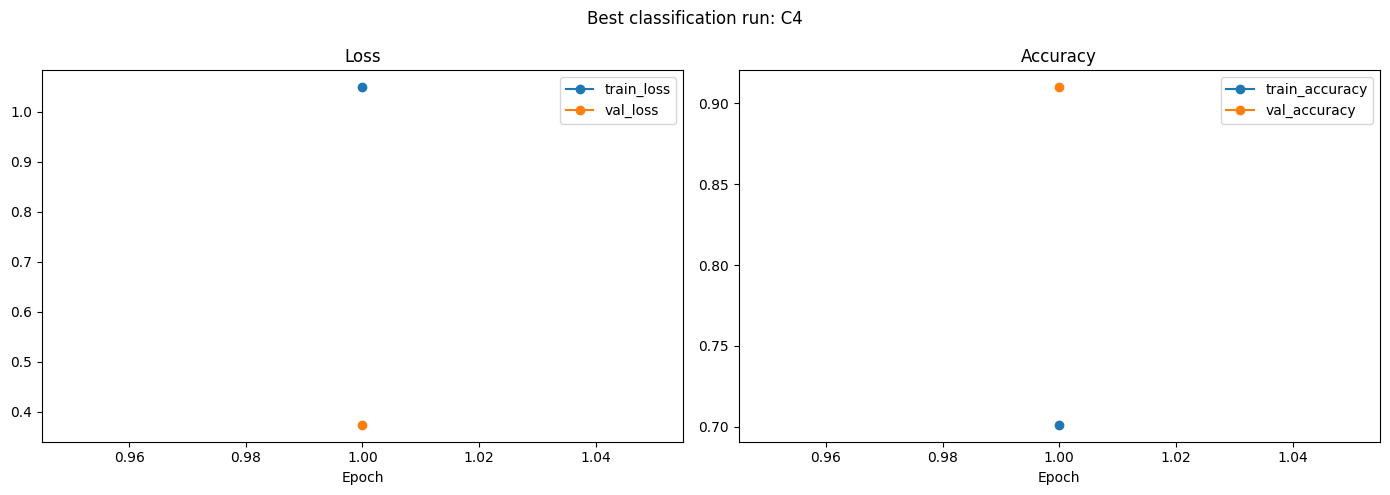

Saved: c:\Dev\mirea-ai\homeworks\HW10-11\artifacts\figures\classification_curves_best.png


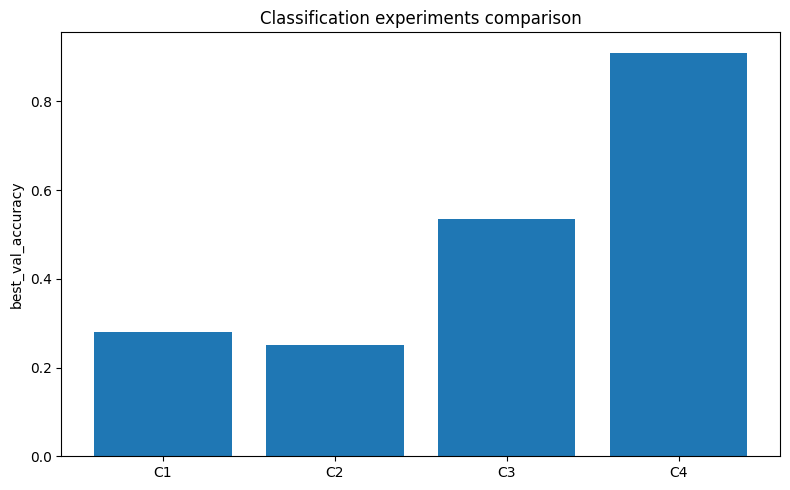

Saved: c:\Dev\mirea-ai\homeworks\HW10-11\artifacts\figures\classification_compare.png


In [7]:
def build_model_by_experiment(experiment_id: str):
    if experiment_id in {"C1", "C2"}:
        model = SimpleCNN(num_classes=NUM_CLASSES_A)
        model_summary = "SimpleCNN(4 conv blocks)"
        test_loader = loaders_a["cnn_base"]["test"] if experiment_id == "C1" else loaders_a["cnn_aug"]["test"]
        transform_name = "base_transform_cnn" if experiment_id == "C1" else "aug_transform_cnn"
    elif experiment_id == "C3":
        model = models.resnet18(weights=None)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES_A)
        model_summary = "ResNet18 pretrained, head-only"
        test_loader = loaders_a["resnet"]["test"]
        transform_name = "resnet_eval_transform"
    elif experiment_id == "C4":
        model = models.resnet18(weights=None)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES_A)
        model_summary = "ResNet18 pretrained, layer4+fc fine-tune"
        test_loader = loaders_a["resnet"]["test"]
        transform_name = "resnet_eval_transform"
    else:
        raise ValueError(f"Unknown experiment_id: {experiment_id}")
    return model, model_summary, test_loader, transform_name

best_exp_id = max(classification_results, key=lambda k: classification_results[k]["best_val_accuracy"])
best_exp = classification_results[best_exp_id]

best_model, best_model_summary, best_test_loader, best_transform_name = build_model_by_experiment(best_exp_id)
best_model.load_state_dict(best_exp["best_state_dict"])
best_model = best_model.to(device)

test_metrics_best = evaluate(best_model, best_test_loader, nn.CrossEntropyLoss(), device)
print(f"Best experiment: {best_exp_id}")
print(test_metrics_best)

best_model_path = ARTIFACTS_DIR / "best_classifier.pt"
torch.save(best_exp["best_state_dict"], best_model_path)

best_config = {
    "dataset": "STL10",
    "seed": SEED,
    "best_experiment_id": best_exp_id,
    "architecture": best_model_summary,
    "train_limit": TRAIN_LIMIT,
    "val_limit": VAL_LIMIT,
    "test_limit": TEST_LIMIT,
    "fast_run": FAST_RUN,
    "batch_size": CLASSIFICATION_BATCH_SIZE,
    "epochs_trained": best_exp["epochs_trained"],
    "optimizer": best_exp["optimizer"],
    "lr": best_exp["lr"],
    "transforms": {
        "base_transform_cnn": "Resize(64,64) -> ToTensor()",
        "aug_transform_cnn": "Resize(72,72) -> RandomCrop(64,64) -> RandomHorizontalFlip -> ColorJitter -> ToTensor()",
        "resnet_train_transform": "Resize(256,256) -> RandomResizedCrop(224) -> RandomHorizontalFlip -> ToTensor() -> Normalize(ImageNet)",
        "resnet_eval_transform": "Resize(256,256) -> CenterCrop(224) -> ToTensor() -> Normalize(ImageNet)",
    },
}
best_config_path = ARTIFACTS_DIR / "best_classifier_config.json"
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

curves_path = FIGURES_DIR / "classification_curves_best.png"
plot_history(best_exp["history"], title=f"Best classification run: {best_exp_id}", save_path=curves_path)

compare_df = pd.DataFrame(
    {
        "experiment_id": list(classification_results.keys()),
        "best_val_accuracy": [classification_results[k]["best_val_accuracy"] for k in classification_results.keys()],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(compare_df["experiment_id"], compare_df["best_val_accuracy"])
ax.set_title("Classification experiments comparison")
ax.set_ylabel("best_val_accuracy")
compare_path = FIGURES_DIR / "classification_compare.png"
fig.tight_layout()
fig.savefig(compare_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {compare_path}")

## 3. Часть B — segmentation на OxfordIIITPet

Выбран **segmentation track**.  
Ground truth сводится к бинарному сценарию **pet vs background**:
- `foreground = trimap != background`
- это означает, что пиксели животного и его пограничная область считаются foreground.

Модель:
- pretrained **DeepLabV3-ResNet50**

Режимы:
- **V1:** базовая постобработка, порог `pet_prob >= 0.40`
- **V2:** альтернативная постобработка, порог `pet_prob >= 0.60`

Альтернативная постобработка здесь — **другой порог бинаризации foreground**, что полностью соответствует требованиям задания.

100.0%
100.0%


Part B batch shapes:
image_for_model.shape = (4, 3, 256, 256)
gt_mask.shape = (4, 256, 256)


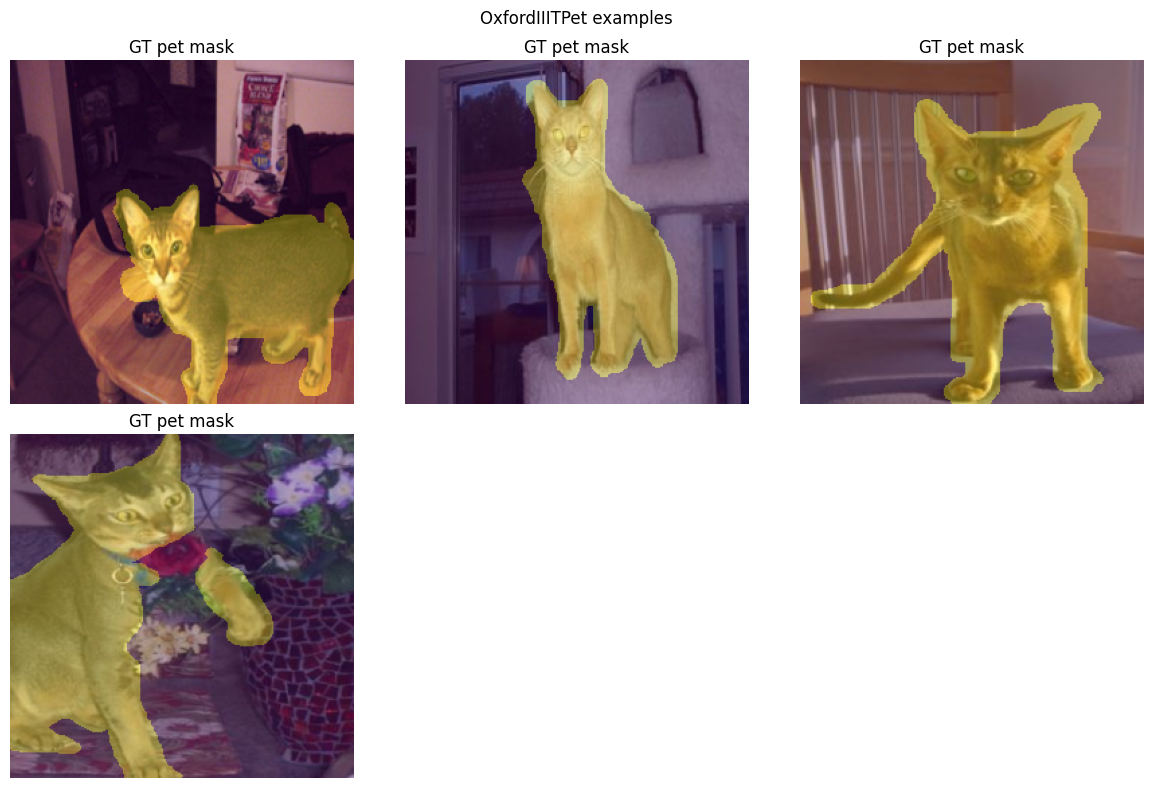

In [8]:
class OxfordPetSegDataset(Dataset):
    def __init__(self, root, split="test", image_size=256, limit=None):
        self.base = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.indices = list(range(len(self.base)))
        if limit is not None:
            self.indices = self.indices[:limit]

        self.image_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

        self.display_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=InterpolationMode.NEAREST),
            transforms.PILToTensor(),
        ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, mask = self.base[self.indices[idx]]
        image_for_model = self.image_transform(image)
        image_for_display = self.display_transform(image)

        mask_tensor = self.mask_transform(mask).squeeze(0).long()
        gt_foreground = (mask_tensor != 2).long()  # 2 = background in trimap

        return image_for_model, gt_foreground, image_for_display

seg_dataset = OxfordPetSegDataset(
    root=DATA_DIR,
    split="test",
    image_size=SEG_IMAGE_SIZE,
    limit=SEGMENTATION_EVAL_LIMIT,
)

seg_loader = DataLoader(
    seg_dataset,
    batch_size=SEGMENTATION_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

seg_images_model, seg_masks_gt, seg_images_display = next(iter(seg_loader))
print("Part B batch shapes:")
print("image_for_model.shape =", tuple(seg_images_model.shape))
print("gt_mask.shape =", tuple(seg_masks_gt.shape))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flatten()):
    if i >= len(seg_images_display):
        ax.axis("off")
        continue
    ax.imshow(seg_images_display[i].permute(1, 2, 0).clamp(0, 1).numpy())
    ax.imshow(seg_masks_gt[i].numpy(), alpha=0.35)
    ax.axis("off")
    ax.set_title("GT pet mask")
fig.suptitle("OxfordIIITPet examples")
fig.tight_layout()
plt.show()

In [9]:
seg_model, seg_weights = build_deeplabv3_resnet50_pretrained()
seg_model = seg_model.to(device)
seg_model.eval()

cat_idx, dog_idx = get_pet_class_indices(seg_weights)
print("cat_idx =", cat_idx, "| dog_idx =", dog_idx)

@torch.no_grad()
def predict_pet_mask(model, x, threshold):
    logits = model(x)["out"]
    probs = torch.softmax(logits, dim=1)
    pet_prob = probs[:, cat_idx] + probs[:, dog_idx]
    pred_mask = (pet_prob >= threshold).long()
    return pred_mask, pet_prob

def segmentation_metrics_from_masks(pred_mask, gt_mask):
    pred_mask = pred_mask.long()
    gt_mask = gt_mask.long()

    tp = ((pred_mask == 1) & (gt_mask == 1)).sum().item()
    fp = ((pred_mask == 1) & (gt_mask == 0)).sum().item()
    fn = ((pred_mask == 0) & (gt_mask == 1)).sum().item()
    union = ((pred_mask == 1) | (gt_mask == 1)).sum().item()
    intersection = ((pred_mask == 1) & (gt_mask == 1)).sum().item()

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    iou = intersection / max(union, 1)
    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "iou": iou,
    }

@torch.no_grad()
def evaluate_segmentation(model, loader, threshold, device):
    all_sample_ious = []
    total_tp, total_fp, total_fn = 0, 0, 0
    visual_samples = []

    for batch_idx, (x_model, y_gt, x_display) in enumerate(loader):
        x_model = x_model.to(device)
        y_gt = y_gt.to(device)

        pred_mask, pet_prob = predict_pet_mask(model, x_model, threshold=threshold)

        for i in range(x_model.size(0)):
            sample_metrics = segmentation_metrics_from_masks(pred_mask[i].cpu(), y_gt[i].cpu())
            all_sample_ious.append(sample_metrics["iou"])
            total_tp += sample_metrics["tp"]
            total_fp += sample_metrics["fp"]
            total_fn += sample_metrics["fn"]

            if len(visual_samples) < 6:
                visual_samples.append({
                    "image": x_display[i].cpu(),
                    "gt_mask": y_gt[i].cpu(),
                    "pred_mask": pred_mask[i].cpu(),
                    "pet_prob": pet_prob[i].cpu(),
                })

    pixel_precision = total_tp / max(total_tp + total_fp, 1)
    pixel_recall = total_tp / max(total_tp + total_fn, 1)
    mean_iou = float(np.mean(all_sample_ious)) if all_sample_ious else 0.0

    return {
        "pixel_precision": pixel_precision,
        "pixel_recall": pixel_recall,
        "mean_iou": mean_iou,
        "visual_samples": visual_samples,
    }

seg_results = {
    "V1": evaluate_segmentation(seg_model, seg_loader, threshold=0.40, device=device),
    "V2": evaluate_segmentation(seg_model, seg_loader, threshold=0.60, device=device),
}

for exp_id, metrics in seg_results.items():
    print(exp_id, {k: v for k, v in metrics.items() if k != "visual_samples"})


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\gidak/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


cat_idx = 8 | dog_idx = 12
V1 {'pixel_precision': 0.9561242287571937, 'pixel_recall': 0.8929353909796465, 'mean_iou': 0.8464367936915046}
V2 {'pixel_precision': 0.9731611679253659, 'pixel_recall': 0.8418496638874201, 'mean_iou': 0.8057695249348534}


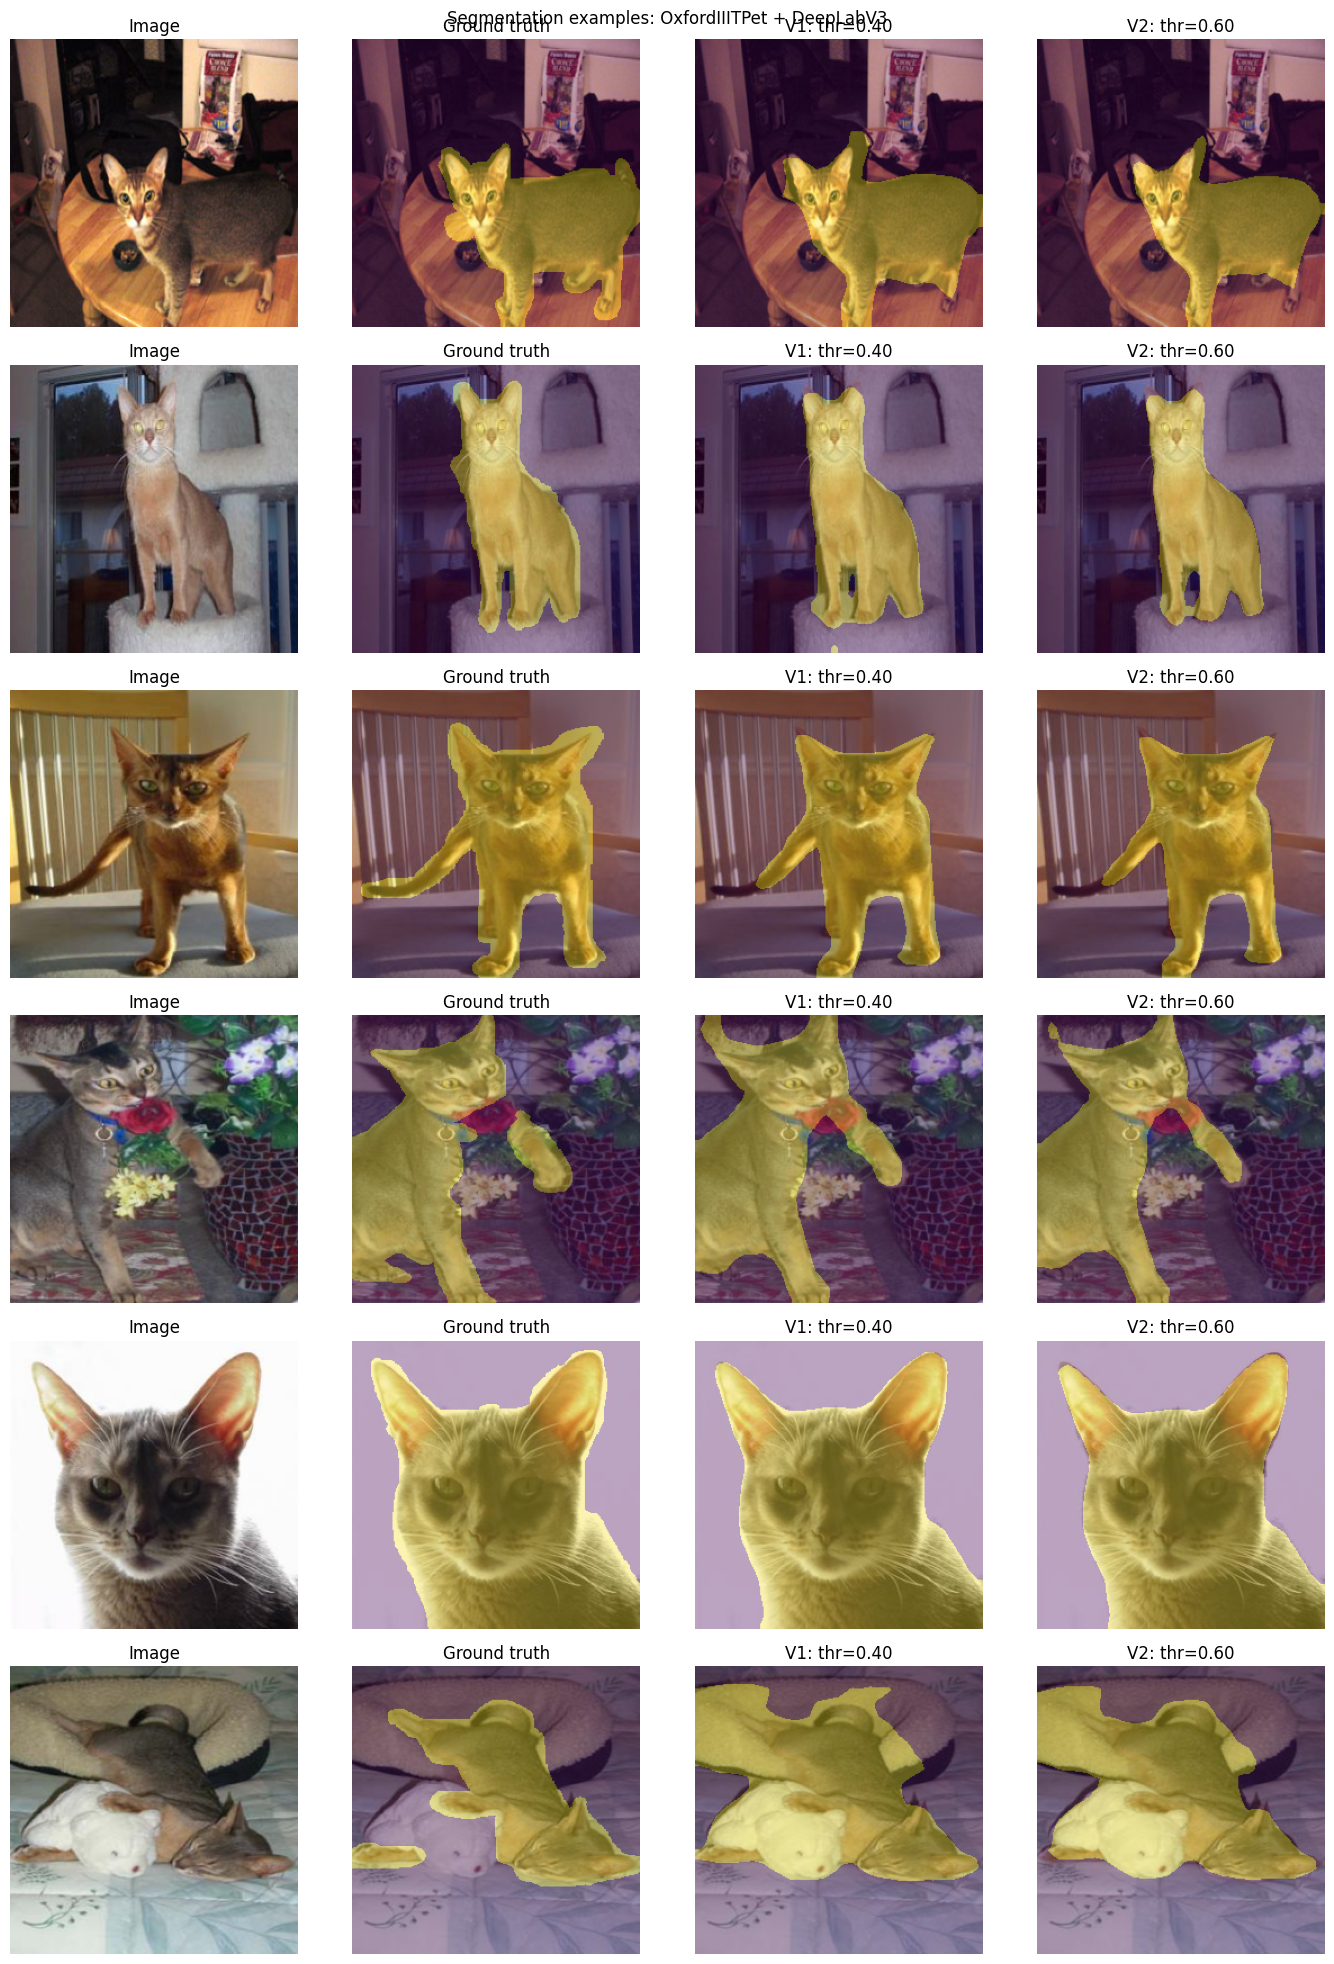

Saved: c:\Dev\mirea-ai\homeworks\HW10-11\artifacts\figures\segmentation_examples.png


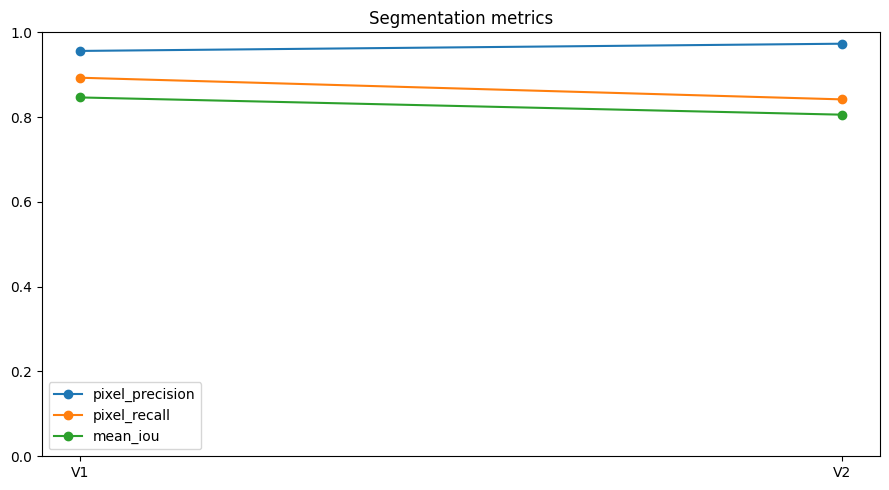

Saved: c:\Dev\mirea-ai\homeworks\HW10-11\artifacts\figures\segmentation_metrics.png


In [10]:
def draw_segmentation_examples(seg_results, save_path):
    fig, axes = plt.subplots(6, 4, figsize=(14, 20))
    samples_v1 = seg_results["V1"]["visual_samples"]
    samples_v2 = seg_results["V2"]["visual_samples"]

    for row in range(6):
        if row >= len(samples_v1):
            for col in range(4):
                axes[row, col].axis("off")
            continue

        sample1 = samples_v1[row]
        sample2 = samples_v2[row]

        image = sample1["image"].permute(1, 2, 0).clamp(0, 1).numpy()
        gt = sample1["gt_mask"].numpy()
        pred1 = sample1["pred_mask"].numpy()
        pred2 = sample2["pred_mask"].numpy()

        axes[row, 0].imshow(image)
        axes[row, 0].axis("off")
        axes[row, 0].set_title("Image")

        axes[row, 1].imshow(image)
        axes[row, 1].imshow(gt, alpha=0.35)
        axes[row, 1].axis("off")
        axes[row, 1].set_title("Ground truth")

        axes[row, 2].imshow(image)
        axes[row, 2].imshow(pred1, alpha=0.35)
        axes[row, 2].axis("off")
        axes[row, 2].set_title("V1: thr=0.40")

        axes[row, 3].imshow(image)
        axes[row, 3].imshow(pred2, alpha=0.35)
        axes[row, 3].axis("off")
        axes[row, 3].set_title("V2: thr=0.60")

    fig.suptitle("Segmentation examples: OxfordIIITPet + DeepLabV3")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

seg_examples_path = FIGURES_DIR / "segmentation_examples.png"
draw_segmentation_examples(seg_results, seg_examples_path)

seg_metrics_df = pd.DataFrame({
    "experiment_id": ["V1", "V2"],
    "pixel_precision": [seg_results["V1"]["pixel_precision"], seg_results["V2"]["pixel_precision"]],
    "pixel_recall": [seg_results["V1"]["pixel_recall"], seg_results["V2"]["pixel_recall"]],
    "mean_iou": [seg_results["V1"]["mean_iou"], seg_results["V2"]["mean_iou"]],
})

fig, ax = plt.subplots(figsize=(9, 5))
for metric_name in ["pixel_precision", "pixel_recall", "mean_iou"]:
    ax.plot(seg_metrics_df["experiment_id"], seg_metrics_df[metric_name], marker="o", label=metric_name)
ax.set_title("Segmentation metrics")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
seg_metrics_path = FIGURES_DIR / "segmentation_metrics.png"
fig.savefig(seg_metrics_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {seg_metrics_path}")

In [11]:
runs_rows = []

for exp_id, result in classification_results.items():
    _, model_summary, _, _ = build_model_by_experiment(exp_id)
    runs_rows.append({
        "experiment_id": exp_id,
        "task": "classification",
        "dataset": "STL10",
        "seed": SEED,
        "model_summary": model_summary,
        "optimizer": result["optimizer"],
        "lr": result["lr"],
        "epochs_trained": result["epochs_trained"],
        "best_val_accuracy": result["best_val_accuracy"],
        "test_accuracy": test_metrics_best["accuracy"] if exp_id == best_exp_id else np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": result["notes"],
    })

runs_rows.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3-ResNet50 pretrained",
    "optimizer": "",
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": seg_results["V1"]["pixel_precision"],
    "recall": seg_results["V1"]["pixel_recall"],
    "mean_iou": seg_results["V1"]["mean_iou"],
    "notes": "foreground = pet vs background; threshold=0.40",
})

runs_rows.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3-ResNet50 pretrained",
    "optimizer": "",
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": seg_results["V2"]["pixel_precision"],
    "recall": seg_results["V2"]["pixel_recall"],
    "mean_iou": seg_results["V2"]["mean_iou"],
    "notes": "foreground = pet vs background; threshold=0.60",
})

runs_df = pd.DataFrame(runs_rows)
runs_csv_path = ARTIFACTS_DIR / "runs.csv"
runs_df.to_csv(runs_csv_path, index=False)
display(runs_df)
print(f"Saved: {runs_csv_path}")

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN(4 conv blocks),Adam,0.0010,1,0.280,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,STL10,42,SimpleCNN(4 conv blocks),Adam,0.0010,1,0.250,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,STL10,42,"ResNet18 pretrained, head-only",AdamW,0.0003,1,0.535,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,STL10,42,"ResNet18 pretrained, layer4+fc fine-tune",AdamW,0.0001,1,0.910,0.89,NaN,NaN,NaN,resnet18-finetune-layer4-fc
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 pretrained,,NaN,0,NaN,NaN,0.956124,0.892935,0.846437,foreground = pet vs background; threshold=0.40
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 pretrained,,NaN,0,NaN,NaN,0.973161,0.841850,0.805770,foreground = pet vs background; threshold=0.60


Saved: c:\Dev\mirea-ai\homeworks\HW10-11\artifacts\runs.csv


## 4. Автогенерация отчёта `report.md`

Следующая ячейка формирует `report.md` **строго по структуре шаблона** и подставляет:
- выбранные датасеты и трек,
- гиперпараметры,
- результаты C1–C4,
- результаты V1–V2,
- ссылки на артефакты.

При повторном запуске ноутбука отчёт будет обновлён автоматически.

In [12]:
def f4(x):
    if x is None:
        return "-"
    try:
        if np.isnan(x):
            return "-"
    except Exception:
        pass
    return f"{x:.4f}" if isinstance(x, (int, float, np.floating)) else str(x)

def build_report_markdown():
    best_val = classification_results[best_exp_id]["best_val_accuracy"]
    test_acc = test_metrics_best["accuracy"]

    c1 = runs_df.loc[runs_df["experiment_id"] == "C1"].iloc[0]
    c2 = runs_df.loc[runs_df["experiment_id"] == "C2"].iloc[0]
    c3 = runs_df.loc[runs_df["experiment_id"] == "C3"].iloc[0]
    c4 = runs_df.loc[runs_df["experiment_id"] == "C4"].iloc[0]
    v1 = runs_df.loc[runs_df["experiment_id"] == "V1"].iloc[0]
    v2 = runs_df.loc[runs_df["experiment_id"] == "V2"].iloc[0]

    aug_delta = (c2["best_val_accuracy"] - c1["best_val_accuracy"]) if pd.notna(c2["best_val_accuracy"]) and pd.notna(c1["best_val_accuracy"]) else np.nan
    ft_delta = (max(c3["best_val_accuracy"], c4["best_val_accuracy"]) - max(c1["best_val_accuracy"], c2["best_val_accuracy"])) if pd.notna(c3["best_val_accuracy"]) and pd.notna(c4["best_val_accuracy"]) else np.nan

    precision_change = (v2["precision"] - v1["precision"]) if pd.notna(v2["precision"]) and pd.notna(v1["precision"]) else np.nan
    recall_change = (v2["recall"] - v1["recall"]) if pd.notna(v2["recall"]) and pd.notna(v1["recall"]) else np.nan

    analysis_lines = [
        "Простая CNN служит базовой точкой отсчёта: она обучается с нуля и показывает, сколько качества можно получить без transfer learning.",
        "Сравнение C1 и C2 показывает влияние аугментаций при одинаковой архитектуре: меняются только train-transforms, поэтому разница интерпретируется достаточно чисто.",
        f"На текущем запуске прирост C2 относительно C1 по best_val_accuracy составил {f4(aug_delta)}.",
        "Pretrained ResNet18 использует признаки, уже выученные на большом внешнем корпусе изображений, поэтому обычно стартует стабильнее и быстрее.",
        "В режиме head-only обновляется только последний классификатор, а в режиме partial fine-tuning дополнительно адаптируется layer4, что делает модель гибче.",
        f"Лучший классификатор в этом запуске — {best_exp_id} с best_val_accuracy={f4(best_val)} и final test_accuracy={f4(test_acc)}.",
        "Во второй части в качестве foreground берётся pet-mask, а качество оценивается через mean IoU как основную метрику пересечения предсказанной и истинной области.",
        f"При переходе от V1 к V2 изменение pixel_precision составило {f4(precision_change)}, а изменение pixel_recall — {f4(recall_change)}.",
        "Повышение порога бинаризации обычно уменьшает ложные срабатывания, но может ухудшать полноту, поэтому precision и recall часто меняются в разные стороны.",
        "Визуально полезно смотреть не только на средние метрики, но и на типовые ошибки: потеря тонких границ, шум по краям и пропуски части объекта.",
    ]

    conclusion_lines = [
        f"В качестве базового конфига классификации для дальнейшей работы я бы выбрал {best_exp_id}, потому что именно он дал лучший validation-результат в текущем прогоне.",
        "Главный вывод по transfer learning: pretrained backbone обычно даёт заметно более сильную стартовую точку, чем обучение с нуля на умеренном датасете.",
        "Главный вывод по segmentation и метрикам: accuracy по изображению целиком здесь недостаточна, а mean IoU, pixel_precision и pixel_recall дают куда более содержательную оценку качества маски.",
    ]

    report = f"""# HW10-11 – компьютерное зрение в PyTorch: CNN, transfer learning, detection/segmentation

## 1. Кратко: что сделано

- Для части A выбран датасет **STL10**, потому что он хорошо подходит для сопоставимого сравнения простой CNN, аугментаций и transfer learning.
- Для части B выбран датасет **OxfordIIITPet** и трек **segmentation**, потому что здесь удобно поставить бинарную задачу `pet vs background`.
- В части A сравнивались эксперименты `C1-C4`: simple CNN без/с аугментациями и pretrained ResNet18 в режимах `head-only` и `partial fine-tuning`.
- Во второй части сравнивались два режима постобработки `V1-V2` для pretrained `DeepLabV3-ResNet50`, отличающиеся порогом бинаризации foreground.

## 2. Среда и воспроизводимость

- Python: рекомендуется 3.10+
- torch / torchvision: {torch.__version__} / {__import__('torchvision').__version__}
- Устройство (CPU/GPU): {device}
- Seed: {SEED}
- Как запустить: открыть `HW10-11.ipynb` и выполнить Run All.
- FAST_RUN: {FAST_RUN} (на CPU включается автоматически для более быстрого end-to-end запуска)

## 3. Данные

### 3.1. Часть A: классификация

- Датасет: `STL10`
- Разделение: `train -> train/val = 80/20` с фиксированным seed, плюс официальный `test`
- Базовые transforms: `Resize(64,64) -> ToTensor()`
- Augmentation transforms: `Resize(72,72) -> RandomCrop(64,64) -> RandomHorizontalFlip -> ColorJitter -> ToTensor()`
- Комментарий (2-4 предложения): STL10 содержит 10 классов естественных изображений. Это удобный учебный датасет для сравнения обучения с нуля и transfer learning. Размер изображений выше, чем у CIFAR, поэтому простая CNN уже может извлекать полезные локальные признаки, но pretrained ResNet18 обычно даёт более сильный baseline.

### 3.2. Часть B: structured vision

- Датасет: `OxfordIIITPet`
- Трек: `segmentation`
- Что считается ground truth: бинарная маска `foreground = pet`, где в trimap foreground задаётся как `mask != background`
- Какие предсказания использовались: вероятности классов `cat` и `dog` из pretrained `DeepLabV3-ResNet50`, сведённые к общей `pet_prob`
- Комментарий (2-4 предложения): для OxfordIIITPet естественно оценивать именно область животного, а не полный multi-class segmentation benchmark. Предобученная модель из torchvision не обучалась специально на этом датасете, но даёт разумный zero-shot / transfer baseline. Это делает постановку воспроизводимой и хорошо подходящей для учебной демонстрации `mean IoU`.

## 4. Часть A: модели и обучение (C1-C4)

Опишите коротко и сопоставимо:

- C1 (simple-cnn-base): `SimpleCNN`, обучение с нуля, базовые transforms
- C2 (simple-cnn-aug): та же `SimpleCNN`, но с train-time аугментациями
- C3 (resnet18-head-only): `ResNet18` с pretrained weights, backbone frozen, обучается только `fc`
- C4 (resnet18-finetune): `ResNet18` с pretrained weights, разморожены `layer4 + fc`

Дополнительно:

- Loss: `CrossEntropyLoss`
- Optimizer(ы): `Adam` для SimpleCNN, `AdamW` для ResNet18
- Batch size: {CLASSIFICATION_BATCH_SIZE}
- Epochs (макс): C1/C2={CNN_EPOCHS}, C3={RESNET_HEAD_EPOCHS}, C4={RESNET_FINETUNE_EPOCHS}
- Критерий выбора лучшей модели: `best_val_accuracy`

## 5. Часть B: постановка задачи и режимы оценки (V1-V2)

### Если выбран segmentation track

- Модель: `DeepLabV3-ResNet50` (pretrained)
- Что считается foreground: объединённый объект `pet` (кошка или собака) против фона
- V1: базовая постобработка — `pet_prob >= 0.40`
- V2: альтернативная постобработка — `pet_prob >= 0.60`
- Как считался mean IoU: для каждой картинки считалось пересечение и объединение бинарных масок `pred vs gt`, затем бралась средняя IoU по выборке
- Считались ли дополнительные pixel-level метрики: да, `pixel_precision` и `pixel_recall`

## 6. Результаты

Ссылки на файлы в репозитории:

- Таблица результатов: `./artifacts/runs.csv`
- Лучшая модель части A: `./artifacts/best_classifier.pt`
- Конфиг лучшей модели части A: `./artifacts/best_classifier_config.json`
- Кривые лучшего прогона классификации: `./artifacts/figures/classification_curves_best.png`
- Сравнение C1-C4: `./artifacts/figures/classification_compare.png`
- Визуализация аугментаций: `./artifacts/figures/augmentations_preview.png`
- Визуализации второй части: `./artifacts/figures/segmentation_examples.png`, `./artifacts/figures/segmentation_metrics.png`

Короткая сводка (6-10 строк):

- Лучший эксперимент части A: {best_exp_id}
- Лучшая `val_accuracy`: {f4(best_val)}
- Итоговая `test_accuracy` лучшего классификатора: {f4(test_acc)}
- Что дали аугментации (C2 vs C1): изменение `best_val_accuracy` = {f4(aug_delta)}
- Что дал transfer learning (C3/C4 vs C1/C2): максимальный прирост относительно лучшего CNN = {f4(ft_delta)}
- Что оказалось лучше: {"partial fine-tuning" if c4["best_val_accuracy"] >= c3["best_val_accuracy"] else "head-only"}
- Что показал режим V1 во второй части: `precision={f4(v1['precision'])}`, `recall={f4(v1['recall'])}`, `mean_iou={f4(v1['mean_iou'])}`
- Что показал режим V2 во второй части: `precision={f4(v2['precision'])}`, `recall={f4(v2['recall'])}`, `mean_iou={f4(v2['mean_iou'])}`
- Как интерпретируются метрики второй части: `mean IoU` показывает степень совпадения масок, `pixel_precision` штрафует лишние пиксели foreground, `pixel_recall` — пропуски объекта

## 7. Анализ

"""
    report += "\n".join([f"- {line}" for line in analysis_lines])
    report += "\n\n## 8. Итоговый вывод\n\n"
    report += "\n".join([f"- {line}" for line in conclusion_lines])
    report += """

## 9. Приложение (опционально)

- При желании можно расширить ноутбук:
  - добавить confusion matrix для лучшего классификатора;
  - сравнить ещё один режим fine-tuning;
  - попробовать третий порог бинаризации или другую постобработку для segmentation;
  - увеличить число эпох и отключить `FAST_RUN` перед финальной сдачей.
"""
    return report

report_text = build_report_markdown()
report_path = ROOT / "report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Saved: {report_path}")
print(report_text[:2500] + "\n\n...")

Saved: c:\Dev\mirea-ai\homeworks\HW10-11\report.md
# HW10-11 – компьютерное зрение в PyTorch: CNN, transfer learning, detection/segmentation

## 1. Кратко: что сделано

- Для части A выбран датасет **STL10**, потому что он хорошо подходит для сопоставимого сравнения простой CNN, аугментаций и transfer learning.
- Для части B выбран датасет **OxfordIIITPet** и трек **segmentation**, потому что здесь удобно поставить бинарную задачу `pet vs background`.
- В части A сравнивались эксперименты `C1-C4`: simple CNN без/с аугментациями и pretrained ResNet18 в режимах `head-only` и `partial fine-tuning`.
- Во второй части сравнивались два режима постобработки `V1-V2` для pretrained `DeepLabV3-ResNet50`, отличающиеся порогом бинаризации foreground.

## 2. Среда и воспроизводимость

- Python: рекомендуется 3.10+
- torch / torchvision: 2.11.0+cpu / 0.26.0+cpu
- Устройство (CPU/GPU): cpu
- Seed: 42
- Как запустить: открыть `HW10-11.ipynb` и выполнить Run All.
- FAST_RUN: True (на CPU включается авт

## 5. Проверка итоговой структуры

После полного запуска ноутбук должен сформировать:

- `homeworks/HW10-11/HW10-11.ipynb`
- `homeworks/HW10-11/report.md`
- `homeworks/HW10-11/artifacts/runs.csv`
- `homeworks/HW10-11/artifacts/best_classifier.pt`
- `homeworks/HW10-11/artifacts/best_classifier_config.json`
- `homeworks/HW10-11/artifacts/figures/classification_curves_best.png`
- `homeworks/HW10-11/artifacts/figures/classification_compare.png`
- `homeworks/HW10-11/artifacts/figures/augmentations_preview.png`
- `homeworks/HW10-11/artifacts/figures/segmentation_examples.png`
- `homeworks/HW10-11/artifacts/figures/segmentation_metrics.png`

Если хотите, можно просто оставить этот ноутбук как основу и уже в своём репозитории выполнить `Run All`.